<a href="https://colab.research.google.com/github/Amogh-S-Acharya/ML2-AMOGH_S_ACHARYA-4NI23CI012/blob/main/kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'social-media-engagement' dataset.
Loading dataset from: /kaggle/input/social-media-engagement/social_media_engagement1.csv

Evaluating optimal K values using Elbow Method...


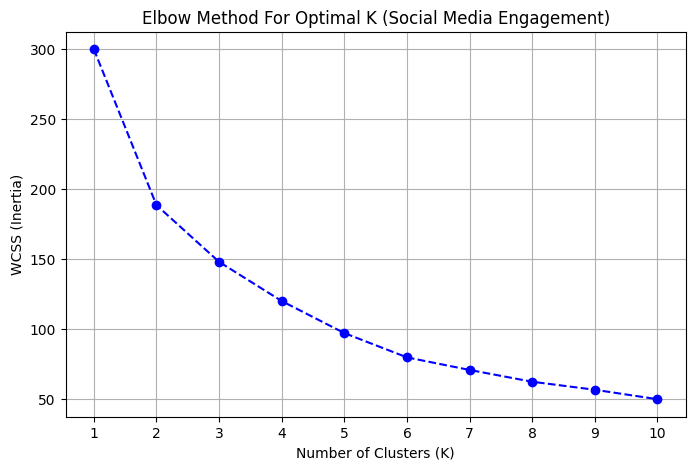


Applying K-Means with K=3...

--- Mean Performance Metrics per Cluster Group ---
               likes    comments      shares
Cluster                                     
0        3079.523810  159.904762  751.619048
1        3510.681818  419.727273  551.500000
2        1689.052632  134.631579  239.438596

--- Cluster Distribution Across Social Media Platforms ---
Cluster     0   1   2
platform             
Facebook    8  10  14
Instagram  13  12  11
Twitter     0   0  32


In [2]:
import os
import glob
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Download the dataset automatically using kagglehub
print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("divyaraj2006/social-media-engagement")

# Locate the actual CSV file inside the downloaded path folder
csv_files = glob.glob(os.path.join(path, "*.csv"))
if not csv_files:
    raise FileNotFoundError("No CSV file found in the downloaded directory.")
dataset_file = csv_files[0]
print(f"Loading dataset from: {dataset_file}\n")

# 2. Load and inspect data
df = pd.read_csv(dataset_file)

# Select the actual numerical metrics present in this dataset for clustering
features = ['likes', 'comments', 'shares']

# Drop missing values and isolate data points
X = df[features].dropna()

# 3. Feature Scaling (Essential for K-Means to weigh distances uniformly)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. The Elbow Method to find the optimal number of clusters (K)
print("Evaluating optimal K values using Elbow Method...")
wcss = []  # Within-Cluster Sum of Squares
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal K (Social Media Engagement)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# 5. Apply K-Means with the chosen K (Typically K=3 or 4 based on engagement types)
optimal_k = 3
print(f"\nApplying K-Means with K={optimal_k}...")
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_assignments = kmeans_model.fit_predict(X_scaled)

# Append the final cluster IDs back to our original dataframe
df_clustered = df.loc[X.index].copy()
df_clustered['Cluster'] = cluster_assignments

# 6. Analyze and Profile the generated clusters
print("\n--- Mean Performance Metrics per Cluster Group ---")
profile = df_clustered.groupby('Cluster')[features].mean()
print(profile)

print("\n--- Cluster Distribution Across Social Media Platforms ---")
print(pd.crosstab(df_clustered['platform'], df_clustered['Cluster']))


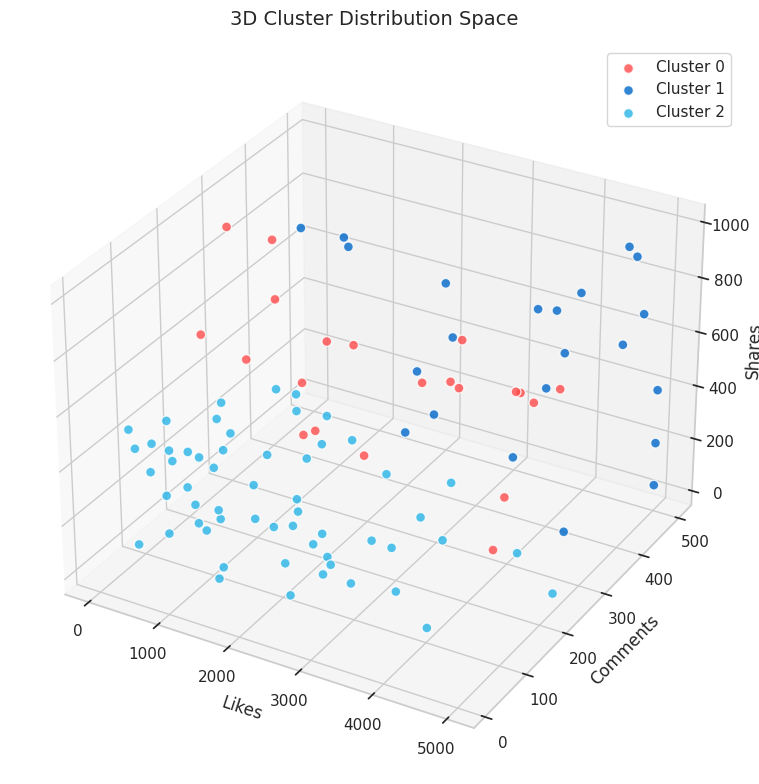

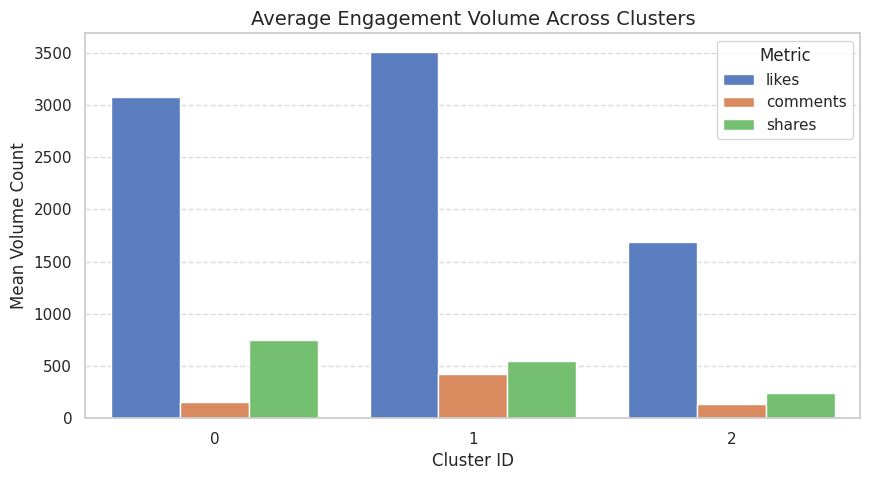

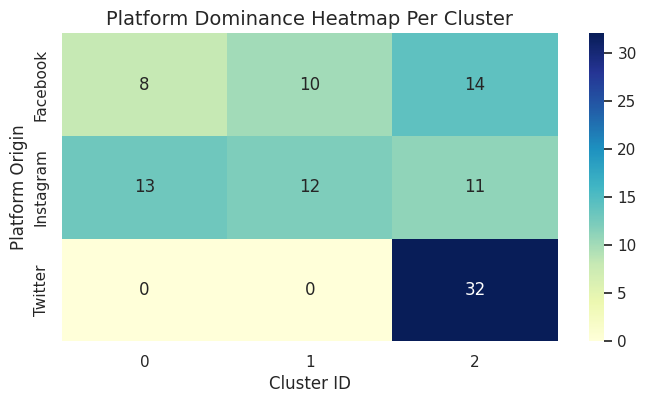

In [3]:
import seaborn as sns

# Ensure styling parameters
sns.set_theme(style='whitegrid')

# 6.1: 3D Scatter Plot of Clusters
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['#FF4B4B', '#0068C9', '#29B5E8', '#FFABAB']

for cluster_id in range(optimal_k):
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id]
    ax.scatter(
        cluster_data['likes'],
        cluster_data['comments'],
        cluster_data['shares'],
        c=colors[cluster_id],
        label=f'Cluster {cluster_id}',
        s=50,
        alpha=0.8,
        edgecolors='w'
    )

ax.set_title('3D Cluster Distribution Space', fontsize=14, pad=15)
ax.set_xlabel('Likes')
ax.set_ylabel('Comments')
ax.set_zlabel('Shares')
ax.legend()
plt.tight_layout()
plt.show()

# 6.2: Group Profile Bar Chart
profile = df_clustered.groupby('Cluster')[features].mean().reset_index()
profile_melted = pd.melt(profile, id_vars='Cluster', var_name='Metric', value_name='Average Value')

plt.figure(figsize=(10, 5))
sns.barplot(data=profile_melted, x='Cluster', y='Average Value', hue='Metric', palette='muted')
plt.title('Average Engagement Volume Across Clusters', fontsize=14)
plt.xlabel('Cluster ID')
plt.ylabel('Mean Volume Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 6.3: Cross-tabulation Platform Heatmap
plt.figure(figsize=(8, 4))
platform_ct = pd.crosstab(df_clustered['platform'], df_clustered['Cluster'])
sns.heatmap(platform_ct, annot=True, fmt='d', cmap='YlGnBu', cbar=True)
plt.title('Platform Dominance Heatmap Per Cluster', fontsize=14)
plt.xlabel('Cluster ID')
plt.ylabel('Platform Origin')
plt.show()
